# *Clustering* with K-means

## Introduction

***Clustering*** is an **unsupervised learning** technique that groups records into groups of similar characteristics, known as ***clusters***.

**K-means** is a clustering algorithm that groups data by attempting to separate samples into $K$ predefined groups, where each sample belongs to the group whose mean (the cluster **centroid**) is closest.

The groups are established by minimizing the **inertia or WCSS (Within-Cluster Sum of Squares)**, which is the sum of squared distances from each sample to the centroid of its group.

- **Inertia** is a measure of how internally coherent clusters are. In the context of K-means, it is also called **Within-Cluster Sum of Squares (WCSS)**.
- For each cluster, WCSS is the sum of the squared distances between each point in the cluster and the centroid of that cluster.
- The total inertia is the sum of WCSS for all clusters:

$$\text{Inertia} = \sum_{i=1}^K \sum_{x \in C_i} \|x - \mu_i\|^2$$

where $C_i$ is the set of points in cluster $i$ and $\mu_i$ is the centroid of cluster $i$.

- Lower inertia means that points are closer to their centroids, indicating more compact clusters.

The K-means algorithm follows these steps:
1. **Initialization**: Choose $K$ initial centroids randomly or using some specific method.
2. **Assignment**: Assign each sample to the nearest centroid.
3. **Update**: Recalculate the centroids as the mean of the samples in each group.
4. **Iteration**: Repeat steps 2 and 3 until the centroids no longer change (the algorithm converges) or a maximum number of iterations is reached.

[![K-means](img/K-means_convergence.gif)](https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif)

## Creating Test Data

We will use the `make_blobs` function from `sklearn.datasets` to generate test data. This function generates a dataset of points distributed as point clouds. We pass the following parameters:
- `n_samples`: total number of samples
- `n_features`: number of features for each sample. We will work with only 2 features to be able to visualize the data in 2D.
- `centers`: number of clusters we want to generate
- `random_state`: seed for random number generation
- `cluster_std`: standard deviation of the clusters

It's important to remember that we are doing this representation process to help understand the algorithm, but we will normally work with datasets of many more dimensions where we cannot visualize the data. In fact, in this case it would normally be easy to divide into clusters by eye. And indeed, we are already generating test data with this `make_blobs` function by indicating the number of clusters we want it to generate.

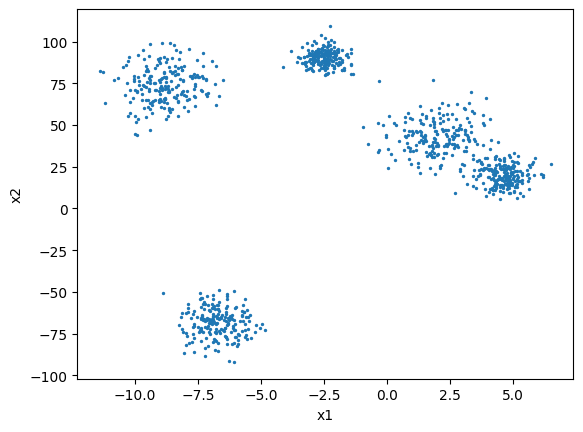

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt

X, y = datasets.make_blobs(n_samples=1000, # Number of samples
                           n_features=2, # Number of features
                           centers=5, # Number of clusters
                           cluster_std=[0.5, 0.6, 0.8, 1, 1.1], # Standard deviation of each cluster
                           random_state=42,) # Seed for reproducibility

# Stretch one axis. This makes feature scaling crucial for K-Means
X[:, 1] = X[:, 1] * 10 

plt.scatter(X[:, 0], X[:, 1], s=2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### Feature Scaling


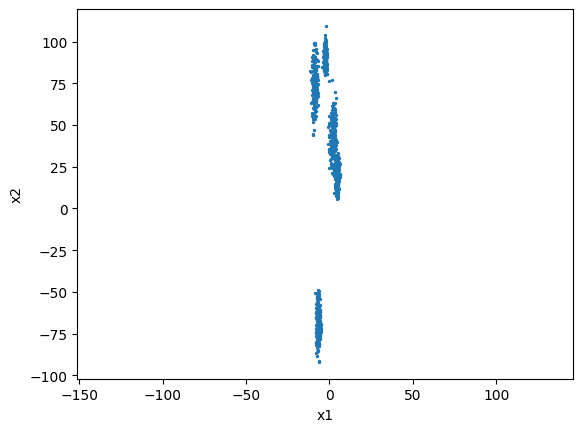

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], s=2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')  # <--- Forces equal scaling
plt.show()


Before applying K-means, it is **CRITICAL** to scale the data (e.g., using `StandardScaler`).

Since K-Means uses Euclidean distance to assign points to clusters, features with larger scales will disproportionately influence the result. If one variable is measured in thousands and another in decimals, the algorithm will naturally cluster based almost entirely on the larger variable, leading to incorrect results.

Standardizing features ensures they contribute equally to the distance calculations.

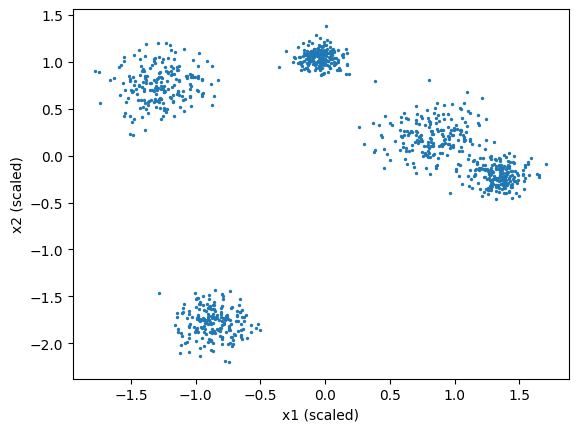

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize scaled data
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=2)
plt.xlabel('x1 (scaled)')
plt.ylabel('x2 (scaled)')
plt.show()

## Training K-means

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5, # Number of clusters (k value)
    n_init='auto',
    random_state=0) # Number of times the algorithm runs with different initial centroids
y_pred = kmeans.fit_predict(X_scaled) # Equivalent to kmeans.fit(X_scaled) and then y_pred = kmeans.predict(X_scaled)

The KMeans constructor receives the following parameters:
* `n_clusters`: The number of clusters to form and the number of centroids to generate. This is what we vary in a loop to find the optimal number of clusters.
* `init`: Method for initializing centroids. The simplest is 'random', but by default it uses 'k-means++', which is a more sophisticated method that tries to place initial centroids far apart from each other.
* `max_iter`: Maximum number of iterations of the algorithm for a single run.
* `n_init`: Number of times the algorithm will be run with different centroids. The final result will be the best output of n_init consecutive runs in terms of inertia.

Like other `scikit-learn` estimators, KMeans has a `fit_predict` method that can be used to train the model and predict the clusters to which the data belongs. This method returns an array of **cluster labels**, which assigns each data point to a cluster, and also stores it in the `labels_` property of the KMeans object.

With the `is` operator we can check if two variables point to the same memory address, that is, if they are the same object. In this case, we are checking if the `labels_` attribute of the KMeans object is the same as the label array returned by the `fit_predict` method:

In [ ]:
y_pred is kmeans.labels_ 

True

The cluster centroids can be obtained with the `cluster_centers_` attribute.

[[ -2.50910651  90.21645302]
 [ -6.72497097 -68.2513756 ]
 [  4.56233973  20.09395426]
 [ -8.82326814  74.01328833]
 [  1.91789139  43.66825325]]


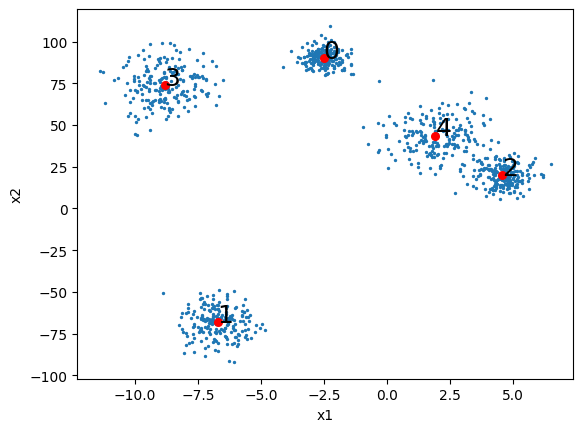

In [ ]:
import matplotlib.pyplot as plt

# Inverse transform centroids to match original data scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print(centroids)

plt.scatter(X[:, 0], X[:, 1], s=2)
plt.scatter(centroids[:,0], centroids[:,1], c='r', s=30)

for i, center in enumerate(centroids):
    plt.annotate(i, center, fontsize=18)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

We can easily predict the cluster to which each new instance belongs with the `predict` method:

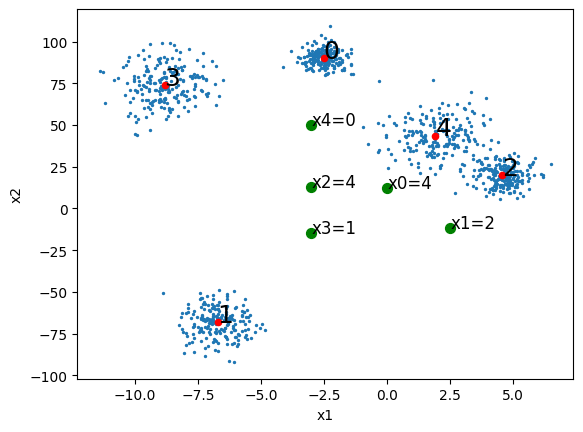

In [ ]:
import numpy as np
X_new = np.array([[0, 12], [2.5, -12], [-3, 13], [-3, -15], [-3, 50]])

X_new_scaled = scaler.transform(X_new)
y_new = kmeans.predict(X_new_scaled)


plt.scatter(X[:, 0], X[:, 1], s=2)
plt.scatter(centroids[:,0], centroids[:,1], c='r', s=20)
plt.scatter(X_new[:, 0], X_new[:, 1], c='g', s=50)

for i, center in enumerate(centroids):
    plt.annotate(i, center, fontsize=18)
    
for i, point in enumerate(X_new): # Annotation for new points
    plt.annotate(f'x{i}={y_new[i]}', point, fontsize=12)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

By plotting the decision boundaries of the algorithm, we obtain a [Voronoi tessellation](https://en.wikipedia.org/wiki/Voronoi_diagram):

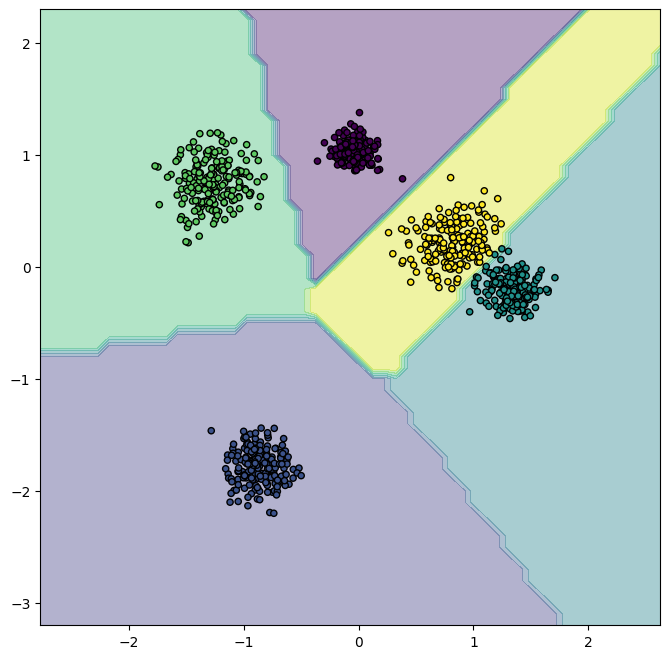

In [ ]:
def plot_decision_regions(kmeans, X):
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 # Min and max values for x1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1 # Min and max values for x2
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                      np.arange(y_min, y_max, 0.1)) 
  
  Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(8, 8))
  plt.contourf(xx, yy, Z, alpha=0.4)
  plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=20, edgecolor='k')
  plt.show()
  
plot_decision_regions(kmeans,X_scaled)

The vast majority of instances were clearly assigned to their original cluster.

The only thing K-means cares about is the distance between instances and centroids. Instead of assigning each instance to a cluster (hard clustering), it's better to give a cluster score per instance (soft clustering). The score can be the distance between the instance and the centroids.

The `transform` method measures the distance between each instance and the centroids.

In [ ]:
kmeans.transform(X_new)

array([[10.96078819, 13.80286573, 12.27911435, 11.32035354, 11.81604276],
       [13.28496709, 10.76351827, 11.85106816, 13.29795998, 12.32750128],
       [12.32079492, 14.92932588, 13.8995097 , 12.3696834 , 13.34579102],
       [16.30958562, 13.39556631, 15.41554209, 15.84584225, 15.68452978],
       [49.04991394, 51.81980656, 50.3931413 , 49.2788106 , 49.9338825 ]])

## Determining the Optimal Number of Clusters

Since K-Means requires us to specify $K$ (number of clusters) beforehand, we need methods to find the best $K$. Two common methods are the **Elbow Method** and the **Silhouette Score**.

### 1. The Elbow Method

The Elbow method looks at the **inertia** (WCSS) as $K$ increases. Inertia always decreases as $K$ increases, but we look for the "elbow" point where the rate of decrease dramatically slows down.

- As $K$ increases, inertia always decreases (or stays the same), because adding more clusters reduces the average distance from points to their closest centroid.
- However, too many clusters can lead to overfitting, so we look for the point where adding more clusters does not significantly reduce inertia—the "elbow" point.

Text(0.5, 1.0, 'Elbow Method')

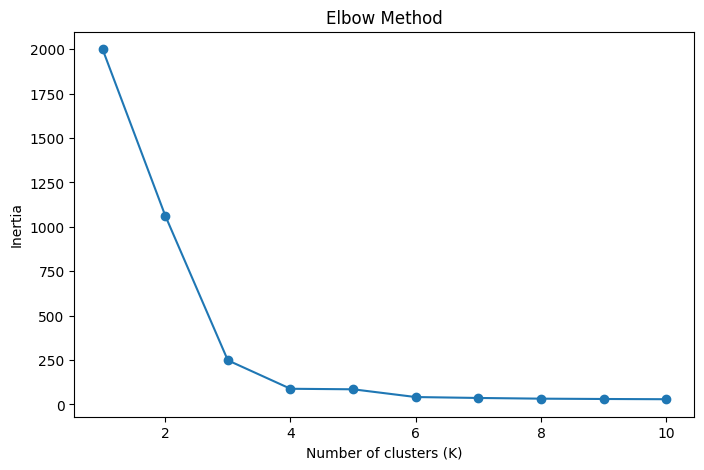

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

The problem os this method is that sometimes there is no clear elbow. Here we could consider that the optimal number of clusters is 3 or 4. That is because even though we generated 5 clusters (centers=5), the random positioning (random_state=42) and the standard deviations likely caused two of the clusters to overlap significantly.

### 2. Silhouette Score

The **Silhouette Score** measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The silhouette ranges from -1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

* **+1**: The sample is far away from the neighboring clusters.
* **0**: The sample is on or very close to the decision boundary between two neighboring clusters.
* **-1**: The sample may have been assigned to the wrong cluster.

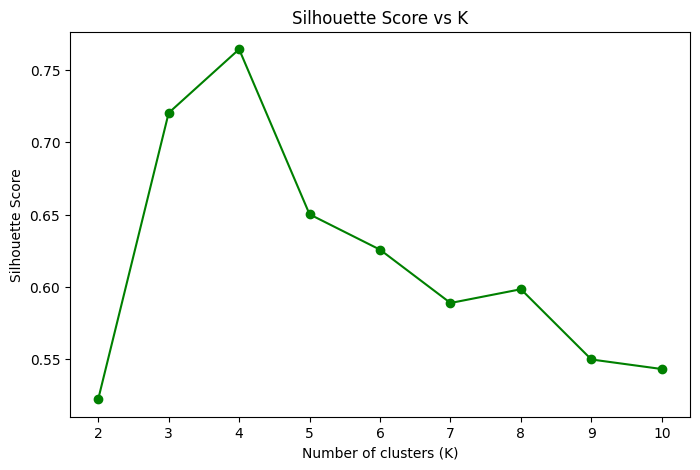

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11) # Silhouette requires at least 2 clusters

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

We can confirm that the higher silhouette score is obtained when using 4 clusters, and in fact, $K$=3 is higher than $K$=5.

## Limitations of K-means

- `K-means` is not perfect, so it is necessary to run the algorithm several times to avoid suboptimal solutions.
- Another limiting factor of the algorithm is that we need to specify the number of clusters.
- `K-means` also doesn't perform very well when groups have different sizes, different densities, or non-spherical shapes.
- Depending on the data, different clustering algorithms may work better (such as `DBSCAN` or `Gaussian Mixtures`).
- Scaling the inputs with a StandardScaler is also essential with `K-means`.

## Additional Resources

- https://github.com/tirthajyoti/Machine-Learning-with-Python/blob/master/Clustering-Dimensionality-Reduction/K_Means_Clustering_Practice.ipynb
- https://scikit-learn.org/stable/modules/clustering.html#k-means
- https://www.datacamp.com/tutorial/k-means-clustering-python
- [StatQuest: K-means clustering](https://www.youtube.com/watch?v=4b5d3muPQmA)